In [2]:
import yfinance as yf
import pymysql
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date
import warnings
warnings.filterwarnings('ignore')

In [4]:
# --- Database connection config ---
DB_CONFIG = {
    'host':     'localhost',
    'port':     3306,
    'user':     'root',
    'password': 'Hes123',
    'database': 'stress_test_db'
}

def get_connection():
    return pymysql.connect(**DB_CONFIG)

# --- Test the connection ---
try:
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT COUNT(*) FROM portfolio")
    count = cursor.fetchone()[0]
    print(f"Connection successful. Portfolio has {count} stocks.")
    conn.close()
except Exception as e:
    print(f"Connection failed: {e}")

Connection successful. Portfolio has 20 stocks.


In [5]:
# --- Pull 2 years of daily price data from Yahoo Finance ---

tickers = [
    'AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META',
    'JPM', 'GS', 'BAC', 'MS', 'BLK',
    'XOM', 'CVX', 'COP', 'SLB',
    'JNJ', 'PFE', 'UNH', 'ABBV',
    'AMZN', 'TSLA'
]

def fetch_and_store_prices(tickers):
    conn = get_connection()
    cursor = conn.cursor()
    
    total_rows = 0
    
    for ticker in tickers:
        print(f"Fetching {ticker}...", end=' ')
        
        # Pull 2 years of daily data
        df = yf.download(ticker, period='2y', interval='1d', progress=False)
        
        # Keep only the Close price and flatten column index
        df = df[['Close']].copy()
        df.columns = ['close_price']
        df.index.name = 'price_date'
        df = df.reset_index()
        
        # Calculate daily return: (today - yesterday) / yesterday
        df['daily_return'] = df['close_price'].pct_change()
        
        # Drop the first row (no return calculable)
        df = df.dropna()
        
        # Write each row into MySQL
        rows_inserted = 0
        for _, row in df.iterrows():
            try:
                cursor.execute("""
                    INSERT IGNORE INTO price_history 
                        (ticker, price_date, close_price, daily_return)
                    VALUES (%s, %s, %s, %s)
                """, (
                    ticker,
                    row['price_date'].date(),
                    round(float(row['close_price']), 4),
                    round(float(row['daily_return']), 6)
                ))
                rows_inserted += 1
            except Exception as e:
                print(f"Row error: {e}")
        
        total_rows += rows_inserted
        print(f"{rows_inserted} rows inserted.")
    
    conn.commit()
    conn.close()
    print(f"\nDone. Total rows written to price_history: {total_rows}")

fetch_and_store_prices(tickers)

Fetching AAPL... 500 rows inserted.
Fetching MSFT... 500 rows inserted.
Fetching NVDA... 500 rows inserted.
Fetching GOOGL... 500 rows inserted.
Fetching META... 500 rows inserted.
Fetching JPM... 500 rows inserted.
Fetching GS... 500 rows inserted.
Fetching BAC... 500 rows inserted.
Fetching MS... 500 rows inserted.
Fetching BLK... 500 rows inserted.
Fetching XOM... 500 rows inserted.
Fetching CVX... 500 rows inserted.
Fetching COP... 500 rows inserted.
Fetching SLB... 500 rows inserted.
Fetching JNJ... 500 rows inserted.
Fetching PFE... 500 rows inserted.
Fetching UNH... 500 rows inserted.
Fetching ABBV... 500 rows inserted.
Fetching AMZN... 500 rows inserted.
Fetching TSLA... 500 rows inserted.

Done. Total rows written to price_history: 10000


In [6]:
# These are the exact dates the crises played out in markets
crisis_windows = {
    '2008 Financial Crisis': ('2008-09-01', '2008-11-30'),
    'COVID Crash 2020':      ('2020-02-01', '2020-03-31')
}

print("Crisis windows defined:")
for name, (start, end) in crisis_windows.items():
    print(f"  {name}: {start} to {end}")

Crisis windows defined:
  2008 Financial Crisis: 2008-09-01 to 2008-11-30
  COVID Crash 2020: 2020-02-01 to 2020-03-31


In [7]:
# We need to go back further than 2 years so we fetch separately for crisis periods
# price_history only has 2 years — crisis data needs its own pull from Yahoo

def fetch_crisis_prices(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, interval='1d', progress=False)
    df = df[['Close']].copy()
    df.columns = ['close_price']
    df.index.name = 'price_date'
    df = df.reset_index()
    return df

# Test with one ticker first
test = fetch_crisis_prices('AAPL', '2008-09-01', '2008-11-30')
print(test.head())
print(f"Rows returned: {len(test)}")

  price_date  close_price
0 2008-09-02     4.979551
1 2008-09-03     5.002622
2 2008-09-04     4.830636
3 2008-09-05     4.799475
4 2008-09-08     4.731758
Rows returned: 63


In [8]:
# Peak-to-trough = (lowest price in window - highest price before crash) / highest price
# This gives us the actual worst-case return experienced during the crisis

def calculate_shock(ticker, start, end):
    df = fetch_crisis_prices(ticker, start, end)
    
    if df.empty or len(df) < 2:
        print(f"  No data for {ticker}")
        return None
    
    peak  = df['close_price'].max()   # highest price in the window
    trough = df['close_price'].min()  # lowest price in the window
    
    # shock = how far it fell from peak to trough
    shock = (trough - peak) / peak
    
    return round(float(shock), 4)

# Test with Apple in 2008
shock = calculate_shock('AAPL', '2008-09-01', '2008-11-30')
print(f"AAPL shock during 2008 crisis: {shock*100:.2f}%")

AAPL shock during 2008 crisis: -51.79%


In [9]:
conn = get_connection()
cursor = conn.cursor()

total_inserted = 0

for scenario_name, (start, end) in crisis_windows.items():
    print(f"\nCalculating shocks for: {scenario_name}")
    print(f"  Window: {start} to {end}")
    print("-" * 45)
    
    for ticker in tickers:
        shock = calculate_shock(ticker, start, end)
        
        if shock is None:
            continue
        
        print(f"  {ticker:6s}  shock: {shock*100:+.2f}%")
        
        # Write into scenarios table
        cursor.execute("""
            INSERT INTO scenarios (scenario_name, ticker, shock_pct)
            VALUES (%s, %s, %s)
            ON DUPLICATE KEY UPDATE shock_pct = VALUES(shock_pct)
        """, (scenario_name, ticker, shock))
        
        total_inserted += 1

conn.commit()
conn.close()
print(f"\nDone. {total_inserted} scenario shocks written to MySQL.")


Calculating shocks for: 2008 Financial Crisis
  Window: 2008-09-01 to 2008-11-30
---------------------------------------------
  AAPL    shock: -51.79%
  MSFT    shock: -36.10%
  NVDA    shock: -52.11%
  GOOGL   shock: -44.67%


$META: possibly delisted; no price data found  (1d 2008-09-01 -> 2008-11-30) (Yahoo error = "Data doesn't exist for startDate = 1220241600, endDate = 1228021200")

1 Failed download:
['META']: possibly delisted; no price data found  (1d 2008-09-01 -> 2008-11-30) (Yahoo error = "Data doesn't exist for startDate = 1220241600, endDate = 1228021200")


  No data for META
  JPM     shock: -54.42%
  GS      shock: -69.27%
  BAC     shock: -70.50%
  MS      shock: -78.47%
  BLK     shock: -55.80%
  XOM     shock: -23.36%
  CVX     shock: -34.13%
  COP     shock: -46.65%
  SLB     shock: -56.34%
  JNJ     shock: -22.72%
  PFE     shock: -23.41%
  UNH     shock: -45.59%


$ABBV: possibly delisted; no price data found  (1d 2008-09-01 -> 2008-11-30) (Yahoo error = "Data doesn't exist for startDate = 1220241600, endDate = 1228021200")

1 Failed download:
['ABBV']: possibly delisted; no price data found  (1d 2008-09-01 -> 2008-11-30) (Yahoo error = "Data doesn't exist for startDate = 1220241600, endDate = 1228021200")


  No data for ABBV
  AMZN    shock: -56.97%


$TSLA: possibly delisted; no price data found  (1d 2008-09-01 -> 2008-11-30) (Yahoo error = "Data doesn't exist for startDate = 1220241600, endDate = 1228021200")

1 Failed download:
['TSLA']: possibly delisted; no price data found  (1d 2008-09-01 -> 2008-11-30) (Yahoo error = "Data doesn't exist for startDate = 1220241600, endDate = 1228021200")


  No data for TSLA

Calculating shocks for: COVID Crash 2020
  Window: 2020-02-01 to 2020-03-31
---------------------------------------------
  AAPL    shock: -31.43%
  MSFT    shock: -28.04%
  NVDA    shock: -37.55%
  GOOGL   shock: -30.87%
  META    shock: -32.96%
  JPM     shock: -42.73%
  GS      shock: -44.41%
  BAC     shock: -47.89%
  MS      shock: -50.61%
  BLK     shock: -42.37%
  XOM     shock: -49.14%
  CVX     shock: -51.04%
  COP     shock: -61.80%
  SLB     shock: -65.62%
  JNJ     shock: -27.37%
  PFE     shock: -25.54%
  UNH     shock: -35.90%
  ABBV    shock: -34.04%
  AMZN    shock: -22.74%
  TSLA    shock: -60.63%

Done. 37 scenario shocks written to MySQL.


In [10]:
# Sector average shocks from what we already calculated for 2008
sector_averages_2008 = {
    'Technology': (-0.5179 + -0.3610 + -0.5211 + -0.4467) / 4,  # AAPL, MSFT, NVDA, GOOGL
    'Financials':  (-0.5442 + -0.6927 + -0.7050 + -0.7847 + -0.5580) / 5,
    'Healthcare':  (-0.2272 + -0.2341 + -0.4559) / 3
}

missing_stocks = {
    'META':  ('Technology', '2008 Financial Crisis'),
    'ABBV':  ('Healthcare', '2008 Financial Crisis'),
    'TSLA':  ('Consumer',   '2008 Financial Crisis')
}

# Consumer has no proxy so we use a broad market approximation
# S&P 500 dropped ~38% in 2008 — TSLA as a high-beta consumer stock gets 1.5x that
sector_averages_2008['Consumer'] = -0.57

conn = get_connection()
cursor = conn.cursor()

print("Filling missing 2008 shocks using sector averages:")
print("-" * 50)

for ticker, (sector, scenario) in missing_stocks.items():
    shock = round(sector_averages_2008[sector], 4)
    print(f"  {ticker:6s}  sector: {sector:12s}  imputed shock: {shock*100:+.2f}%")
    
    cursor.execute("""
        INSERT INTO scenarios (scenario_name, ticker, shock_pct)
        VALUES (%s, %s, %s)
        ON DUPLICATE KEY UPDATE shock_pct = VALUES(shock_pct)
    """, (scenario, ticker, shock))

conn.commit()
conn.close()
print("\nMissing shocks written to MySQL.")

Filling missing 2008 shocks using sector averages:
--------------------------------------------------
  META    sector: Technology    imputed shock: -46.17%
  ABBV    sector: Healthcare    imputed shock: -30.57%
  TSLA    sector: Consumer      imputed shock: -57.00%

Missing shocks written to MySQL.


In [11]:
conn = get_connection()
cursor = conn.cursor()

cursor.execute("""
    SELECT scenario_name, COUNT(*) as tickers,
           MIN(shock_pct) as worst_shock,
           MAX(shock_pct) as best_shock
    FROM scenarios
    GROUP BY scenario_name
    ORDER BY scenario_name
""")

rows = cursor.fetchall()
conn.close()

print(rows)

(('2008 Financial Crisis', 20, Decimal('-0.7847'), Decimal('-0.2272')), ('COVID Crash 2020', 20, Decimal('-0.6562'), Decimal('-0.2274')), ('Rate Hike +200bps', 20, Decimal('-0.3500'), Decimal('0.0600')))


**Calculating VAR and CVar**

In [12]:
# Pull portfolio weights from MySQL
def load_portfolio():
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT ticker, position_usd, weight_pct, sector FROM portfolio")
    rows = cursor.fetchall()
    conn.close()
    
    df = pd.DataFrame(rows, columns=['ticker', 'position_usd', 'weight_pct', 'sector'])
    return df

# Pull 2 years of daily returns from MySQL
def load_returns():
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("""
        SELECT ticker, price_date, daily_return 
        FROM price_history 
        ORDER BY ticker, price_date
    """)
    rows = cursor.fetchall()
    conn.close()
    
    df = pd.DataFrame(rows, columns=['ticker', 'price_date', 'daily_return'])
    
    # Pivot so each column is a ticker, each row is a date
    df_pivot = df.pivot(index='price_date', columns='ticker', values='daily_return')
    df_pivot = df_pivot.dropna()  # drop any dates where any ticker has missing data
    
    return df_pivot

portfolio = load_portfolio()
returns   = load_returns()

print("Portfolio:")
print(portfolio)
print(f"\nReturns matrix shape: {returns.shape}")
print(f"Date range: {returns.index[0]} to {returns.index[-1]}")

Portfolio:
   ticker position_usd weight_pct      sector
0    AAPL    120000.00     0.0600  Technology
1    MSFT    110000.00     0.0550  Technology
2    NVDA    100000.00     0.0500  Technology
3   GOOGL     90000.00     0.0450  Technology
4    META     80000.00     0.0400  Technology
5     JPM    110000.00     0.0550  Financials
6      GS     90000.00     0.0450  Financials
7     BAC     80000.00     0.0400  Financials
8      MS     70000.00     0.0350  Financials
9     BLK     50000.00     0.0250  Financials
10    XOM     90000.00     0.0450      Energy
11    CVX     70000.00     0.0350      Energy
12    COP     60000.00     0.0300      Energy
13    SLB     80000.00     0.0400      Energy
14    JNJ     80000.00     0.0400  Healthcare
15    PFE     60000.00     0.0300  Healthcare
16    UNH     80000.00     0.0400  Healthcare
17   ABBV     80000.00     0.0400  Healthcare
18   AMZN    110000.00     0.0550    Consumer
19   TSLA     90000.00     0.0450    Consumer

Returns matrix shape: 

In [14]:
def load_returns():
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("""
        SELECT ticker, price_date, daily_return 
        FROM price_history 
        ORDER BY ticker, price_date
    """)
    rows = cursor.fetchall()
    conn.close()
    
    df = pd.DataFrame(rows, columns=['ticker', 'price_date', 'daily_return'])
    
    # Convert Decimal to float — MySQL returns Decimal type, numpy needs float
    df['daily_return'] = df['daily_return'].astype(float)
    
    df_pivot = df.pivot(index='price_date', columns='ticker', values='daily_return')
    df_pivot = df_pivot.dropna()
    
    return df_pivot

# Also fix portfolio position_usd to float
def load_portfolio():
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT ticker, position_usd, weight_pct, sector FROM portfolio")
    rows = cursor.fetchall()
    conn.close()
    
    df = pd.DataFrame(rows, columns=['ticker', 'position_usd', 'weight_pct', 'sector'])
    
    # Convert Decimal to float
    df['position_usd'] = df['position_usd'].astype(float)
    df['weight_pct']   = df['weight_pct'].astype(float)
    
    return df

portfolio = load_portfolio()
returns   = load_returns()

print("Portfolio loaded:", len(portfolio), "stocks")
print("Returns matrix shape:", returns.shape)
print("Date range:", returns.index[0], "to", returns.index[-1])

Portfolio loaded: 20 stocks
Returns matrix shape: (500, 20)
Date range: 2024-04-19 to 2026-04-17


In [21]:
def calculate_var_cvar(returns_df, portfolio_df, confidence=0.95):
    
    # Step 1: align weights to match column order of returns matrix
    weights = portfolio_df.set_index('ticker')['weight_pct']
    weights = weights.reindex(returns_df.columns)  # same order as return columns
    weights = weights / weights.sum()              # normalise to sum to 1.0
    
    # Step 2: calculate daily portfolio return
    # multiply each stock's return by its weight, sum across all stocks for each day
    # e.g. day 1: (AAPL_return × 0.06) + (MSFT_return × 0.055) + ... = portfolio_return
    portfolio_daily_returns = returns_df.dot(weights)
    
    # Step 3: convert returns to dollar P&L
    total_portfolio_value = portfolio_df['position_usd'].sum()  # $2,000,000
    portfolio_pnl = portfolio_daily_returns * total_portfolio_value
    
    # Step 4: Historical VaR
    # Sort all daily P&L from worst to best
    # VaR 95% = the loss at the 5th percentile (worst 5% of days)
    var_95 = np.percentile(portfolio_pnl, 5)
    
    # Step 5: CVaR (Expected Shortfall)
    # Take only the days WORSE than VaR, average them
    # This is the average loss on your worst 5% of days
    cvar_95 = portfolio_pnl[portfolio_pnl <= var_95].mean()
    
    # Step 6: Max Drawdown
    # Cumulative portfolio value over time
    cumulative = (1 + portfolio_daily_returns).cumprod() * total_portfolio_value
    rolling_peak = cumulative.cummax()         # highest value seen so far at each point
    drawdown = (cumulative - rolling_peak) / rolling_peak  # how far below peak
    max_drawdown = drawdown.min()              # worst point
    
    return {
        'portfolio_pnl':    round(float(portfolio_pnl.sum()), 2),
        'var_95':           round(float(var_95), 2),
        'cvar_95':          round(float(cvar_95), 2),
        'max_drawdown':     round(float(max_drawdown), 4),
        'daily_pnl_series': portfolio_pnl      # keep for charting later
    }

results = calculate_var_cvar(returns, portfolio)

print("=" * 45)
print("  PORTFOLIO RISK METRICS (2-Year History)")
print("=" * 45)
print(f"  Total Portfolio Value : ${portfolio['position_usd'].sum():>12,.0f}")
print(f"  Daily VaR  (95%)      : ${results['var_95']:>12,.0f}")
print(f"  Daily CVaR (95%)      : ${results['cvar_95']:>12,.0f}")
print(f"  Max Drawdown          : {results['max_drawdown']*100:>11.2f}%")
print("=" * 45)

  PORTFOLIO RISK METRICS (2-Year History)
  Total Portfolio Value : $   1,700,000
  Daily VaR  (95%)      : $     -28,335
  Daily CVaR (95%)      : $     -44,880
  Max Drawdown          :      -20.44%


**Calculating Stress Scenarios**

In [22]:
def calculate_scenario_pnl(scenario_name, portfolio_df):
    
    # Load shocks for this scenario from MySQL
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("""
        SELECT s.ticker, s.shock_pct, p.position_usd
        FROM scenarios s
        JOIN portfolio p ON s.ticker = p.ticker
        WHERE s.scenario_name = %s
    """, (scenario_name,))
    rows = cursor.fetchall()
    conn.close()
    
    total_pnl = 0
    stock_pnl = []
    
    for ticker, shock_pct, position_usd in rows:
        # P&L for this stock = position size × shock
        # e.g. AAPL: $120,000 × -0.518 = -$62,160
        pnl = float(position_usd) * float(shock_pct)
        total_pnl += pnl
        stock_pnl.append({
            'ticker':       ticker,
            'position_usd': float(position_usd),
            'shock_pct':    float(shock_pct),
            'pnl':          round(pnl, 2)
        })
    
    return round(total_pnl, 2), pd.DataFrame(stock_pnl)

# Run all 3 scenarios
scenarios = ['2008 Financial Crisis', 'COVID Crash 2020', 'Rate Hike +200bps']

print(f"{'Scenario':<25} {'Stressed P&L':>15} {'% of Portfolio':>16}")
print("-" * 58)

for scenario in scenarios:
    pnl, breakdown = calculate_scenario_pnl(scenario, portfolio)
    pct = (pnl / portfolio['position_usd'].sum()) * 100
    print(f"{scenario:<25} ${pnl:>14,.0f} {pct:>15.2f}%")

Scenario                     Stressed P&L   % of Portfolio
----------------------------------------------------------
2008 Financial Crisis     $      -817,635          -48.10%
COVID Crash 2020          $      -684,440          -40.26%
Rate Hike +200bps         $      -156,400           -9.20%


In [23]:
# writing to Sql 
conn = get_connection()
cursor = conn.cursor()

for scenario in scenarios:
    pnl, _ = calculate_scenario_pnl(scenario, portfolio)
    
    cursor.execute("""
        INSERT INTO stress_results 
            (scenario_name, portfolio_pnl, var_95, cvar_95, max_drawdown)
        VALUES (%s, %s, %s, %s, %s)
    """, (
        scenario,
        pnl,
        results['var_95'],
        results['cvar_95'],
        results['max_drawdown']
    ))

conn.commit()
conn.close()
print("All results written to stress_results table.")

All results written to stress_results table.


In [18]:
# Diagnose the mismatch
print("Sum of position_usd:", portfolio['position_usd'].sum())
print("Sum of weight_pct:",   portfolio['weight_pct'].sum())
print()
print(portfolio[['ticker', 'sector', 'position_usd', 'weight_pct']])

Sum of position_usd: 1700000.0
Sum of weight_pct: 0.8500000000000001

   ticker      sector  position_usd  weight_pct
0    AAPL  Technology      120000.0       0.060
1    MSFT  Technology      110000.0       0.055
2    NVDA  Technology      100000.0       0.050
3   GOOGL  Technology       90000.0       0.045
4    META  Technology       80000.0       0.040
5     JPM  Financials      110000.0       0.055
6      GS  Financials       90000.0       0.045
7     BAC  Financials       80000.0       0.040
8      MS  Financials       70000.0       0.035
9     BLK  Financials       50000.0       0.025
10    XOM      Energy       90000.0       0.045
11    CVX      Energy       70000.0       0.035
12    COP      Energy       60000.0       0.030
13    SLB      Energy       80000.0       0.040
14    JNJ  Healthcare       80000.0       0.040
15    PFE  Healthcare       60000.0       0.030
16    UNH  Healthcare       80000.0       0.040
17   ABBV  Healthcare       80000.0       0.040
18   AMZN    Consu

In [19]:
# Simply update the total value variable to reflect reality
# No recalculation needed — just make sure we reference the correct sum everywhere

total_value = portfolio['position_usd'].sum()
print(f"Actual portfolio value: ${total_value:,.0f}")

# Confirm VaR as % of portfolio — this is what matters
print(f"VaR  as % of portfolio: {(results['var_95'] / total_value)*100:.2f}%")
print(f"CVaR as % of portfolio: {(results['cvar_95'] / total_value)*100:.2f}%")

Actual portfolio value: $1,700,000
VaR  as % of portfolio: -1.67%
CVaR as % of portfolio: -2.64%


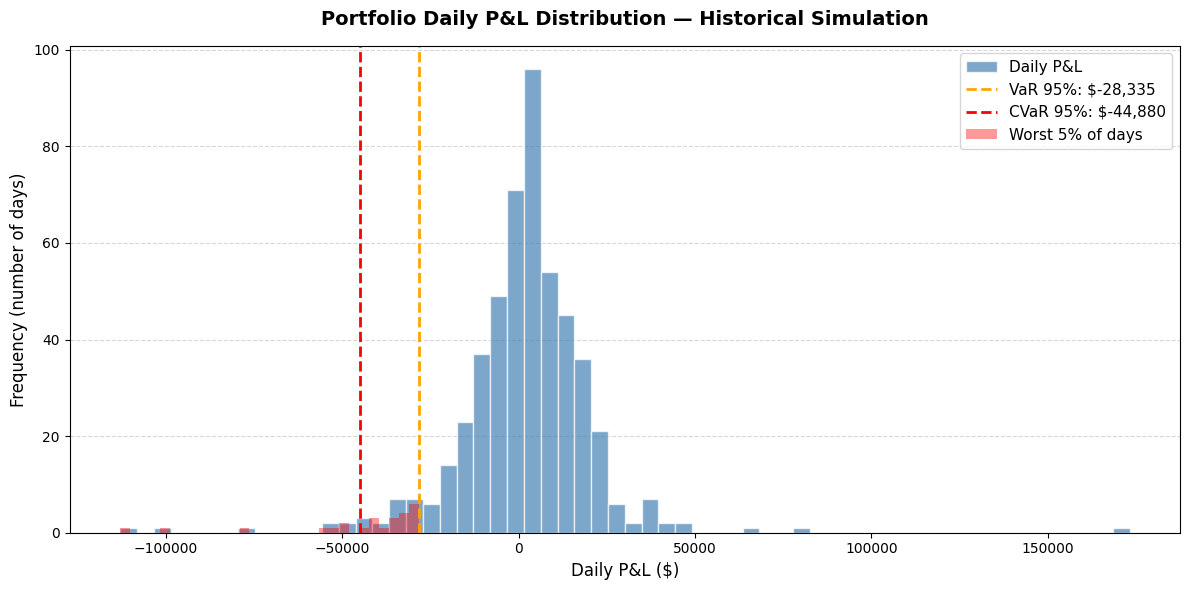

Chart 1 saved.


In [24]:
#  Daily P&L distribution with VaR and CVaR marked
fig, ax = plt.subplots(figsize=(12, 6))

daily_pnl = results['daily_pnl_series']

# Plot the distribution
ax.hist(daily_pnl, bins=60, color='steelblue', edgecolor='white', 
        alpha=0.7, label='Daily P&L')

# VaR line
ax.axvline(x=results['var_95'], color='orange', linewidth=2, 
           linestyle='--', label=f"VaR 95%: ${results['var_95']:,.0f}")

# CVaR line
ax.axvline(x=results['cvar_95'], color='red', linewidth=2, 
           linestyle='--', label=f"CVaR 95%: ${results['cvar_95']:,.0f}")

# Shade the tail (worst 5%)
tail = daily_pnl[daily_pnl <= results['var_95']]
ax.hist(tail, bins=30, color='red', alpha=0.4, label='Worst 5% of days')

# Labels
ax.set_title('Portfolio Daily P&L Distribution — Historical Simulation', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Daily P&L ($)', fontsize=12)
ax.set_ylabel('Frequency (number of days)', fontsize=12)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart1_pnl_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

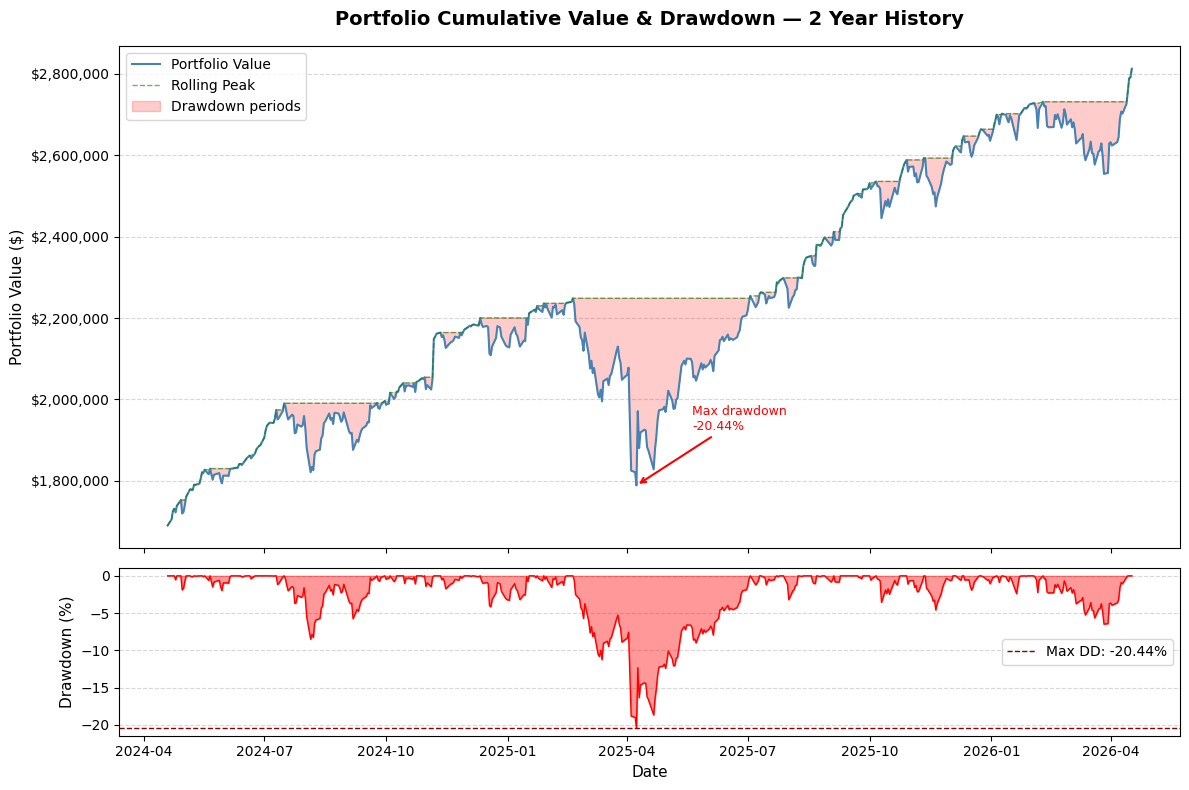

Chart 2 saved.


In [25]:
#Portfolio cumulative return over 2 years with max drawdown highlighted
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, 
                                gridspec_kw={'height_ratios': [3, 1]})

# --- Calculate cumulative portfolio value ---
daily_returns = results['daily_pnl_series'] / portfolio['position_usd'].sum()
cumulative    = (1 + daily_returns).cumprod() * portfolio['position_usd'].sum()
rolling_peak  = cumulative.cummax()
drawdown      = (cumulative - rolling_peak) / rolling_peak * 100

# --- Top chart: cumulative portfolio value ---
ax1.plot(cumulative.index, cumulative.values, 
         color='steelblue', linewidth=1.5, label='Portfolio Value')
ax1.plot(cumulative.index, rolling_peak.values, 
         color='green', linewidth=1, linestyle='--', 
         alpha=0.6, label='Rolling Peak')

# Shade drawdown periods on top chart
ax1.fill_between(cumulative.index, cumulative.values, rolling_peak.values,
                 where=(cumulative.values < rolling_peak.values),
                 color='red', alpha=0.2, label='Drawdown periods')

# Mark max drawdown point
max_dd_date = drawdown.idxmin()
max_dd_val  = cumulative[max_dd_date]
ax1.annotate(f'Max drawdown\n{results["max_drawdown"]*100:.2f}%',
             xy=(max_dd_date, max_dd_val),
             xytext=(40, 40), textcoords='offset points',
             fontsize=9, color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax1.set_title('Portfolio Cumulative Value & Drawdown — 2 Year History',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Portfolio Value ($)', fontsize=11)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=10)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)

# --- Bottom chart: drawdown % over time ---
ax2.fill_between(drawdown.index, drawdown.values, 0,
                 color='red', alpha=0.4)
ax2.plot(drawdown.index, drawdown.values, color='red', linewidth=1)
ax2.axhline(y=results['max_drawdown']*100, color='darkred',
            linewidth=1, linestyle='--',
            label=f"Max DD: {results['max_drawdown']*100:.2f}%")

ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(fontsize=10)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart2_cumulative_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

Sector P&L breakdown:
                       Consumer    Energy  Financials  Healthcare  Technology
2008 Financial Crisis -113967.0 -117977.0   -261434.0    -93150.0   -231107.0
COVID Crash 2020       -79581.0 -169530.0   -181896.0    -93172.0   -160261.0
Rate Hike +200bps      -55700.0    1000.0     12400.0    -19600.0    -94500.0


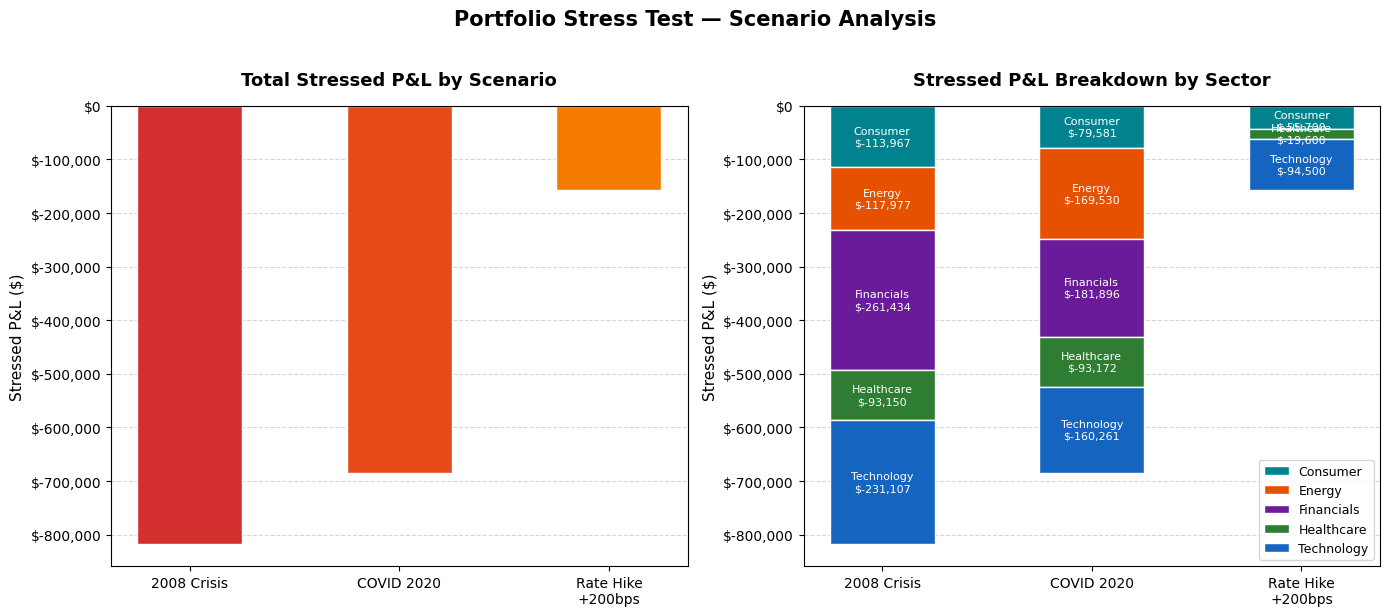

Chart 3 saved.


In [26]:
# --- Build scenario breakdown by sector ---
scenario_sector_data = {}

for scenario in scenarios:
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("""
        SELECT p.sector,
               SUM(p.position_usd * s.shock_pct) as sector_pnl
        FROM scenarios s
        JOIN portfolio p ON s.ticker = p.ticker
        WHERE s.scenario_name = %s
        GROUP BY p.sector
        ORDER BY p.sector
    """, (scenario,))
    rows = cursor.fetchall()
    conn.close()
    
    scenario_sector_data[scenario] = {
        row[0]: round(float(row[1]), 2) for row in rows
    }

# Convert to DataFrame
sector_df = pd.DataFrame(scenario_sector_data).T
print("Sector P&L breakdown:")
print(sector_df.to_string())

# --- Plot stacked bar chart ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left chart: total stressed P&L per scenario
scenario_totals = sector_df.sum(axis=1)
colors = ['#d32f2f', '#e64a19', '#f57c00']
bars = ax1.bar(range(len(scenarios)), scenario_totals.values,
               color=colors, edgecolor='white', width=0.5)

# Add value labels on bars
for bar, val in zip(bars, scenario_totals.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 15000,
             f'${val:,.0f}',
             ha='center', va='top',
             color='white', fontsize=10, fontweight='bold')

ax1.set_xticks(range(len(scenarios)))
ax1.set_xticklabels(['2008 Crisis', 'COVID 2020', 'Rate Hike\n+200bps'],
                    fontsize=10)
ax1.set_title('Total Stressed P&L by Scenario', fontsize=13, 
              fontweight='bold', pad=15)
ax1.set_ylabel('Stressed P&L ($)', fontsize=11)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)

# Right chart: stacked bar breakdown by sector
sector_colors = {
    'Technology': '#1565c0',
    'Financials':  '#6a1b9a',
    'Energy':      '#e65100',
    'Healthcare':  '#2e7d32',
    'Consumer':    '#00838f'
}

bottom = np.zeros(len(scenarios))
for sector in sector_df.columns:
    values = sector_df[sector].values
    color  = sector_colors.get(sector, '#888888')
    ax2.bar(range(len(scenarios)), values,
            bottom=bottom, label=sector,
            color=color, edgecolor='white', width=0.5)
    
    # Add sector label inside bar if large enough
    for i, (val, bot) in enumerate(zip(values, bottom)):
        if abs(val) > 15000:
            ax2.text(i, bot + val/2,
                     f'{sector}\n${val:,.0f}',
                     ha='center', va='center',
                     color='white', fontsize=8)
    bottom += values

ax2.set_xticks(range(len(scenarios)))
ax2.set_xticklabels(['2008 Crisis', 'COVID 2020', 'Rate Hike\n+200bps'],
                    fontsize=10)
ax2.set_title('Stressed P&L Breakdown by Sector', fontsize=13,
              fontweight='bold', pad=15)
ax2.set_ylabel('Stressed P&L ($)', fontsize=11)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(loc='lower right', fontsize=9)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)

plt.suptitle('Portfolio Stress Test — Scenario Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")